<a href="https://colab.research.google.com/github/arturbernardo/data_sus/blob/main/estatuto_do_desarmamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
pip install polars

In [2]:
import math
import polars as pl
import panda as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
from sqlalchemy import create_engine
from sqlalchemy import text
from getpass import getpass
from dateutil.relativedelta import relativedelta

In [3]:
%%capture
uri = "https://raw.githubusercontent.com/arturbernardo/municipios-brasileiros/refs/heads/main/csv/municipios.csv"
!wget -U "Mozilla" -O municipios.csv {uri}

In [4]:
%%capture
uri = "https://raw.githubusercontent.com/arturbernardo/municipios-brasileiros/refs/heads/main/csv/estados.csv"
!wget -U "Mozilla" -O estados.csv {uri}

In [5]:
%%capture
uri = "https://github.com/arturbernardo/CidDataSus/raw/refs/heads/master/CIDImport/Repositorio/Resources/CID-10-SUBCATEGORIAS.CSV"
!wget -U "Mozilla" -O CID-10-SUBCATEGORIAS.CSV {uri}

In [11]:
%%capture
path = "/content/CID-10-SUBCATEGORIAS.CSV"
columns_subcat = ['SUBCAT', 'CLASSIF', 'RESTRSEXO', 'CAUSAOBITO', 'DESCRICAO', 'DESCRABREV', 'REFER', 'EXCLUIDOS']
sub_categorias = pl.read_csv(path, separator=";", columns=columns_subcat, encoding="latin-1", quote_char=None)

In [22]:
%%capture
# 1996 - 2020 https://diaad.s3.sa-east-1.amazonaws.com/sim/Mortalidade_Geral_1979.csv
!wget -U "Mozilla" -O mortalidade_2004.csv https://diaad.s3.sa-east-1.amazonaws.com/sim/Mortalidade_Geral_2004.csv
!wget -U "Mozilla" -O mortalidade_2003.csv https://diaad.s3.sa-east-1.amazonaws.com/sim/Mortalidade_Geral_2003.csv

In [23]:

columns=["CAUSABAS", "IDADE", "SEXO", "RACACOR", "LOCOCOR", "DTNASC", "DTOBITO", "CODMUNOCOR"]

df_2004 = pl.read_csv("mortalidade_2004.csv", separator=";",encoding="latin-1", null_values=["null"], columns=columns, infer_schema=False)
df_2003 = pl.read_csv("mortalidade_2003.csv", separator=";",encoding="latin-1", null_values=["null"], columns=columns, infer_schema=False)


In [26]:
df_combined = pl.concat([df_2003, df_2004])
print(df_combined.head())

shape: (5, 8)
┌──────────┬──────────┬───────┬──────┬─────────┬─────────┬────────────┬──────────┐
│ DTOBITO  ┆ DTNASC   ┆ IDADE ┆ SEXO ┆ RACACOR ┆ LOCOCOR ┆ CODMUNOCOR ┆ CAUSABAS │
│ ---      ┆ ---      ┆ ---   ┆ ---  ┆ ---     ┆ ---     ┆ ---        ┆ ---      │
│ str      ┆ str      ┆ str   ┆ str  ┆ str     ┆ str     ┆ str        ┆ str      │
╞══════════╪══════════╪═══════╪══════╪═════════╪═════════╪════════════╪══════════╡
│ 11012003 ┆ 23121946 ┆ 456   ┆ 1    ┆ null    ┆ 3       ┆ 1200336    ┆ F102     │
│ 21012003 ┆ 17011958 ┆ 445   ┆ 2    ┆ 4       ┆ 5       ┆ 1200336    ┆ B54      │
│ 16012003 ┆ 29051944 ┆ 458   ┆ 1    ┆ 1       ┆ 1       ┆ 1200401    ┆ E142     │
│ 03012003 ┆ 06031920 ┆ 482   ┆ 2    ┆ 1       ┆ 1       ┆ 1200401    ┆ I678     │
│ 23012003 ┆ 26031937 ┆ 465   ┆ 1    ┆ null    ┆ 3       ┆ 1200401    ┆ I219     │
└──────────┴──────────┴───────┴──────┴─────────┴─────────┴────────────┴──────────┘


In [25]:
mortalidade_causa = df_combined.join(sub_categorias, left_on="CAUSABAS", right_on="SUBCAT", how="left")

In [ ]:
mortalidade_causa

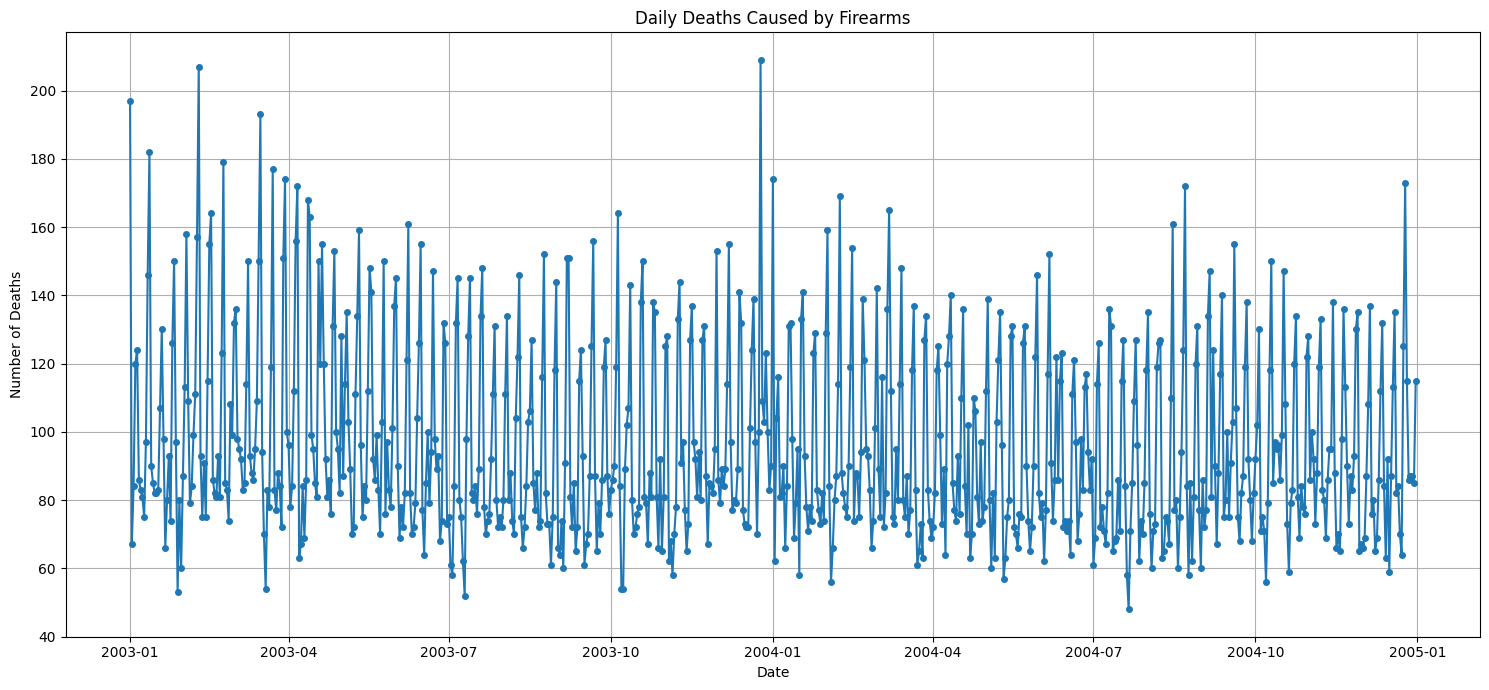

In [33]:
import polars as pl
import matplotlib.pyplot as plt

# Identify firearm-related causes based on common ICD-10 codes or keywords in description
# Common ICD-10 codes for firearm injuries often start with W32-W34, X72-X74, X93-X95, Y22-Y24
# Let's search for keywords like "arma de fogo" (firearm) or "projetil" (projectile) in descriptions
# X93, X94, X95
firearm_codes = sub_categorias.filter(
    # (pl.col('SUBCAT').str.starts_with('W32')) |
    # (pl.col('SUBCAT').str.starts_with('W33')) |
    # (pl.col('SUBCAT').str.starts_with('W34')) |
    # (pl.col('SUBCAT').str.starts_with('X72')) |
    # (pl.col('SUBCAT').str.starts_with('X73')) |
    # (pl.col('SUBCAT').str.starts_with('X74')) |
    (pl.col('SUBCAT').str.starts_with('X93')) |
    (pl.col('SUBCAT').str.starts_with('X94')) |
    (pl.col('SUBCAT').str.starts_with('X95'))
    # (pl.col('SUBCAT').str.starts_with('Y22')) |
    # (pl.col('SUBCAT').str.starts_with('Y23')) |
    # (pl.col('SUBCAT').str.starts_with('Y24')) |
    # (pl.col('DESCRICAO').str.to_lowercase().str.contains('arma de fogo')) |
    # (pl.col('DESCRICAO').str.to_lowercase().str.contains('projetil'))
)['SUBCAT'].unique().to_list()


# Filter the main DataFrame for these causes
deaths_by_firearm = mortalidade_causa.filter(
    pl.col('CAUSABAS').is_in(firearm_codes)
)

# Convert DTOBITO to datetime and count daily occurrences
daily_firearm_deaths = deaths_by_firearm.with_columns(
    pl.col('DTOBITO').str.strptime(pl.Date, format='%d%m%Y', strict=False).alias('DATE_OBITO')
).group_by('DATE_OBITO').agg(pl.len().alias('DEATH_COUNT')).sort('DATE_OBITO')

# Plotting the data
plt.figure(figsize=(15, 7))
plt.plot(daily_firearm_deaths['DATE_OBITO'], daily_firearm_deaths['DEATH_COUNT'], marker='o', linestyle='-', markersize=4)
plt.title('Daily Deaths Caused by Firearms')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.grid(True)
plt.tight_layout()
plt.show()

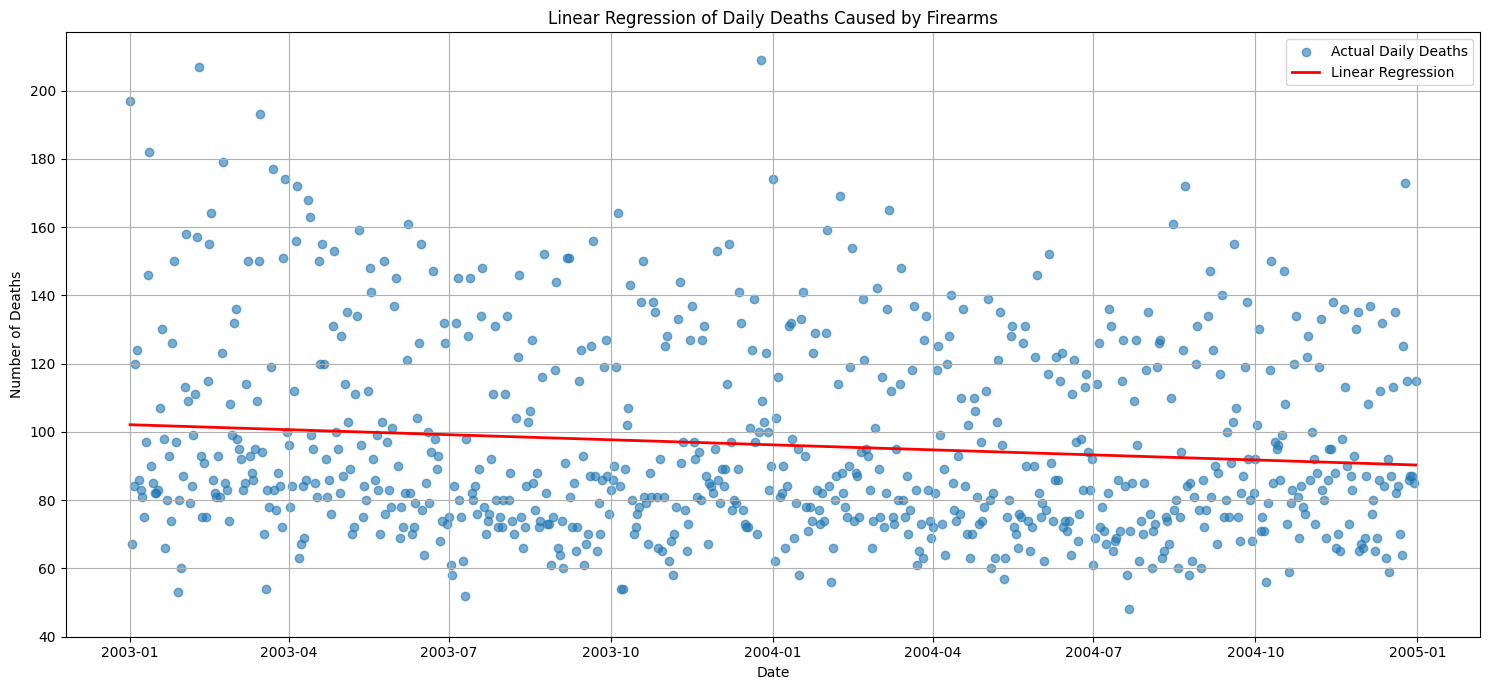

Coefficient (Slope): -0.02
Intercept: 11922.77


In [34]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Convert DATE_OBITO to numerical format (e.g., ordinal date)
daily_firearm_deaths_pd = daily_firearm_deaths.to_pandas()
daily_firearm_deaths_pd['DATE_ORDINAL'] = daily_firearm_deaths_pd['DATE_OBITO'].apply(lambda date: date.toordinal())

X = daily_firearm_deaths_pd[['DATE_ORDINAL']]
y = daily_firearm_deaths_pd['DEATH_COUNT']

# Create and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Plot the original data and the regression line
plt.figure(figsize=(15, 7))
plt.scatter(daily_firearm_deaths_pd['DATE_OBITO'], y, label='Actual Daily Deaths', alpha=0.6)
plt.plot(daily_firearm_deaths_pd['DATE_OBITO'], y_pred, color='red', label='Linear Regression', linewidth=2)
plt.title('Linear Regression of Daily Deaths Caused by Firearms')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

In [ ]:
distinct_firearm_descriptions = sub_categorias.filter(
    pl.col('SUBCAT').is_in(firearm_codes)
)['DESCRICAO'].unique().sort().to_list()

for description in distinct_firearm_descriptions:
    print(description)

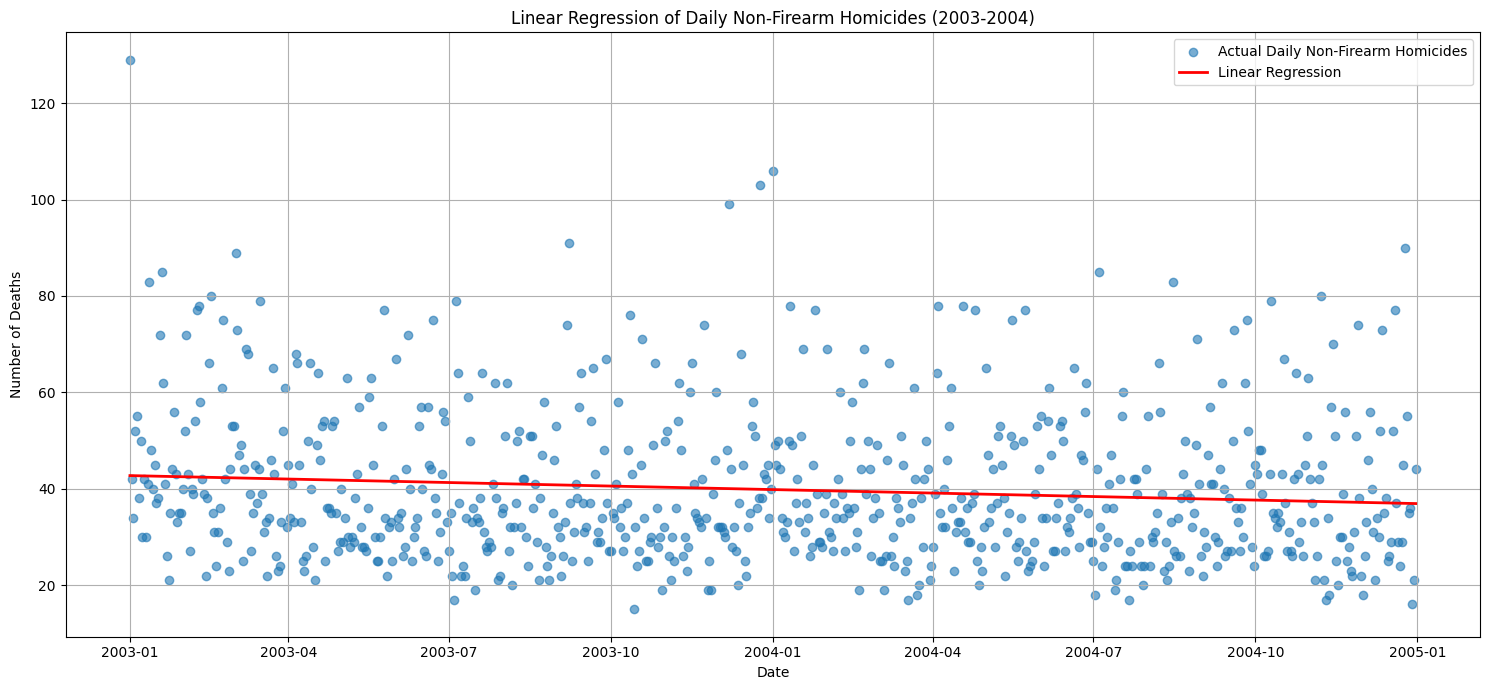

Coefficient (Slope) for Non-Firearm Homicides: -0.01
Intercept for Non-Firearm Homicides: 5851.65


In [31]:
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Identify ICD-10 codes for homicides (X85-Y09)
# And exclude firearm-related codes already identified in `firearm_codes`
#
homicide_codes_raw = sub_categorias.filter(
    (pl.col('SUBCAT').str.starts_with('X85')) |
    (pl.col('SUBCAT').str.starts_with('X86')) |
    (pl.col('SUBCAT').str.starts_with('X87')) |
    (pl.col('SUBCAT').str.starts_with('X88')) |
    (pl.col('SUBCAT').str.starts_with('X89')) |
    (pl.col('SUBCAT').str.starts_with('X90')) |
    (pl.col('SUBCAT').str.starts_with('X91')) |
    (pl.col('SUBCAT').str.starts_with('X92')) |
    (pl.col('SUBCAT').str.starts_with('X96')) |
    (pl.col('SUBCAT').str.starts_with('X97')) |
    (pl.col('SUBCAT').str.starts_with('X98')) |
    (pl.col('SUBCAT').str.starts_with('X99')) |
    (pl.col('SUBCAT').str.starts_with('Y00')) |
    (pl.col('SUBCAT').str.starts_with('Y01')) |
    (pl.col('SUBCAT').str.starts_with('Y02')) |
    (pl.col('SUBCAT').str.starts_with('Y03')) |
    (pl.col('SUBCAT').str.starts_with('Y04')) |
    (pl.col('SUBCAT').str.starts_with('Y05')) |
    (pl.col('SUBCAT').str.starts_with('Y06')) |
    (pl.col('SUBCAT').str.starts_with('Y07')) |
    (pl.col('SUBCAT').str.starts_with('Y08')) |
    (pl.col('SUBCAT').str.starts_with('Y09'))
)['SUBCAT'].unique().to_list()

# Filter out firearm-related codes from homicides
non_firearm_homicide_codes = [code for code in homicide_codes_raw if code not in firearm_codes]

# 2. Filter the combined mortality data for these non-firearm homicide causes
deaths_by_non_firearm_homicide = mortalidade_causa.filter(
    pl.col('CAUSABAS').is_in(non_firearm_homicide_codes)
)

# 3. Convert DTOBITO to datetime and count daily occurrences
daily_non_firearm_homicides = deaths_by_non_firearm_homicide.with_columns(
    pl.col('DTOBITO').str.strptime(pl.Date, format='%d%m%Y', strict=False).alias('DATE_OBITO')
).group_by('DATE_OBITO').agg(pl.len().alias('DEATH_COUNT')).sort('DATE_OBITO')

# 4. Perform Linear Regression
# Convert to Pandas for scikit-learn compatibility
daily_non_firearm_homicides_pd = daily_non_firearm_homicides.to_pandas()
daily_non_firearm_homicides_pd['DATE_ORDINAL'] = daily_non_firearm_homicides_pd['DATE_OBITO'].apply(lambda date: date.toordinal())

X_homicide = daily_non_firearm_homicides_pd[['DATE_ORDINAL']]
y_homicide = daily_non_firearm_homicides_pd['DEATH_COUNT']

model_homicide = LinearRegression()
model_homicide.fit(X_homicide, y_homicide)

y_homicide_pred = model_homicide.predict(X_homicide)

# 5. Plot the original data and the regression line
plt.figure(figsize=(15, 7))
plt.scatter(daily_non_firearm_homicides_pd['DATE_OBITO'], y_homicide, label='Actual Daily Non-Firearm Homicides', alpha=0.6)
plt.plot(daily_non_firearm_homicides_pd['DATE_OBITO'], y_homicide_pred, color='red', label='Linear Regression', linewidth=2)
plt.title('Linear Regression of Daily Non-Firearm Homicides (2003-2004)')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Coefficient (Slope) for Non-Firearm Homicides: {model_homicide.coef_[0]:.2f}")
print(f"Intercept for Non-Firearm Homicides: {model_homicide.intercept_:.2f}")


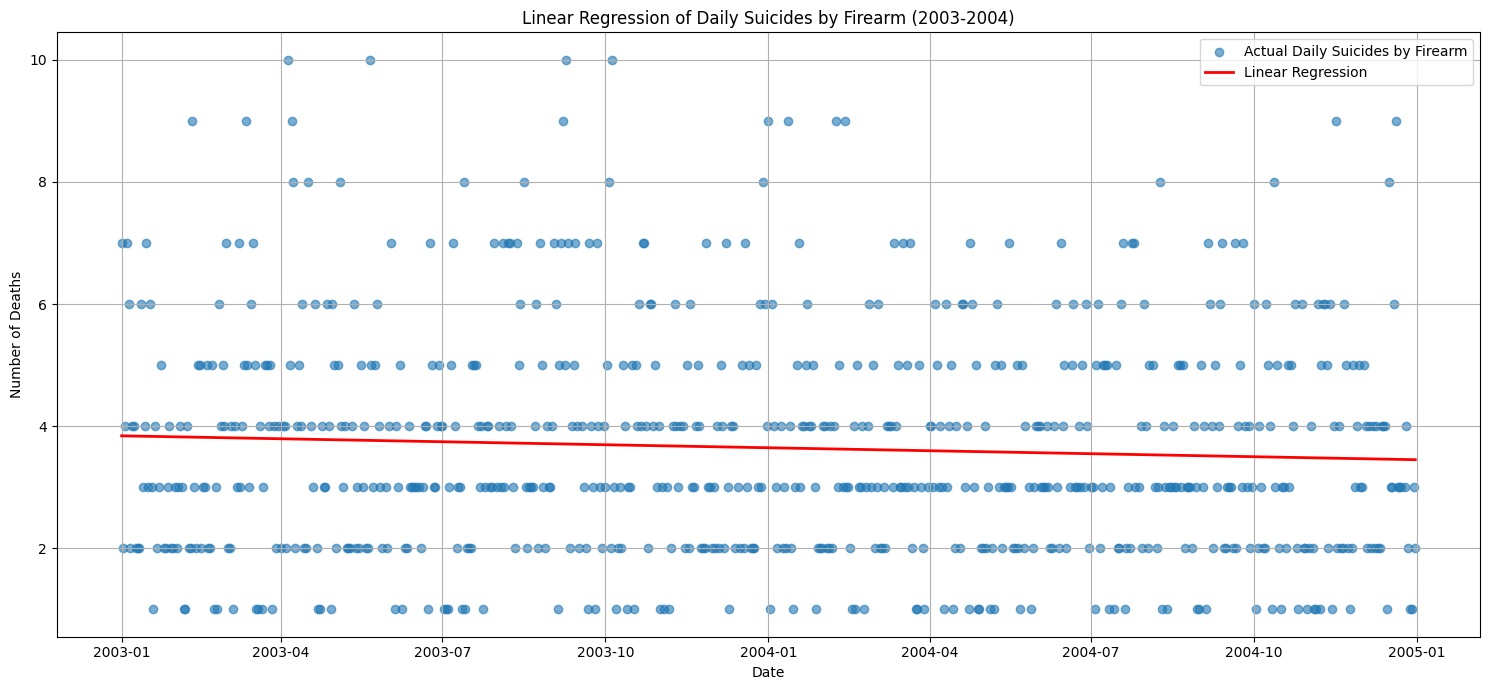

Coefficient (Slope) for Suicides by Firearm: -0.00
Intercept for Suicides by Firearm: 395.44


In [35]:
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Identify ICD-10 codes for suicide by firearm (X72-X74)
suicide_firearm_codes = sub_categorias.filter(
    (pl.col('SUBCAT').str.starts_with('X72')) |
    (pl.col('SUBCAT').str.starts_with('X73')) |
    (pl.col('SUBCAT').str.starts_with('X74'))
)['SUBCAT'].unique().to_list()

# 2. Filter the combined mortality data for these suicide by firearm causes
deaths_by_suicide_firearm = mortalidade_causa.filter(
    pl.col('CAUSABAS').is_in(suicide_firearm_codes)
)

# 3. Convert DTOBITO to datetime and count daily occurrences
daily_suicide_firearm_deaths = deaths_by_suicide_firearm.with_columns(
    pl.col('DTOBITO').str.strptime(pl.Date, format='%d%m%Y', strict=False).alias('DATE_OBITO')
).group_by('DATE_OBITO').agg(pl.len().alias('DEATH_COUNT')).sort('DATE_OBITO')

# 4. Perform Linear Regression
# Convert to Pandas for scikit-learn compatibility
daily_suicide_firearm_deaths_pd = daily_suicide_firearm_deaths.to_pandas()
daily_suicide_firearm_deaths_pd['DATE_ORDINAL'] = daily_suicide_firearm_deaths_pd['DATE_OBITO'].apply(lambda date: date.toordinal())

X_suicide = daily_suicide_firearm_deaths_pd[['DATE_ORDINAL']]
y_suicide = daily_suicide_firearm_deaths_pd['DEATH_COUNT']

model_suicide = LinearRegression()
model_suicide.fit(X_suicide, y_suicide)

y_suicide_pred = model_suicide.predict(X_suicide)

# 5. Plot the original data and the regression line
plt.figure(figsize=(15, 7))
plt.scatter(daily_suicide_firearm_deaths_pd['DATE_OBITO'], y_suicide, label='Actual Daily Suicides by Firearm', alpha=0.6)
plt.plot(daily_suicide_firearm_deaths_pd['DATE_OBITO'], y_suicide_pred, color='red', label='Linear Regression', linewidth=2)
plt.title('Linear Regression of Daily Suicides by Firearm (2003-2004)')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Coefficient (Slope) for Suicides by Firearm: {model_suicide.coef_[0]:.2f}")
print(f"Intercept for Suicides by Firearm: {model_suicide.intercept_:.2f}")
